In [4]:
import pandas as pd
import geopandas as gpd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import shapely as wkt

import folium # For plots of geometry on interactive map
import matplotlib.colors as mcolors
import random

import sys
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data"
print("Data directory:", DATA_DIR.resolve())

benchmark_feeder = "012670401"  # Feeder in Alameda (Oakland) to Potentially use

Data directory: /Users/licin/optimal_charger_placement/OptimalChargerPlacement/data


# Importing Data

# Raw Data Import

### Grid Data

In [5]:
# Import Load data for all feeders

def get_loadDf_for_feeder(feeder_id):
    load_df_all_feeders = import_loadDf_all_feeders()
    feeder_loadDf = load_df_all_feeders[load_df_all_feeders['feeder_id'] == int(feeder_id)]
    renameColsDict = {'low_load_kw':'low_base_load_kw',
                      'high_load_kw': 'high_base_load_kw'}
    feeder_loadDf = feeder_loadDf.rename(columns=renameColsDict)

    return feeder_loadDf


def import_loadDf_all_feeders(base_path=DATA_DIR):

    relative_folder_path = "cleanedGridData"
    filename = "feeder_load_profile_clean.csv"
    file_path = os.path.join(base_path, relative_folder_path, filename)

    load_df_all_feeders = pd.read_csv(file_path)
    return load_df_all_feeders


load_df_all_feeders = import_loadDf_all_feeders()

In [6]:
load_df_all_feeders

,feeder_id,low_load_kw,high_load_kw,month,hour
0,102041101,1057.0,1250.0,1,0
1,102041101,966.0,1117.0,1,1
2,102041101,951.0,1077.0,1,2
3,102041101,938.0,1057.0,1,3
4,102041101,964.0,1104.0,1,4
...,...,...,...,...,...
592411,83912110,4028.0,4944.0,12,19
592412,83912110,4077.0,4989.0,12,20
592413,83912110,4117.0,4962.0,12,21
592414,83912110,4074.0,4871.0,12,22


In [7]:
# Import metadata geodataframe for all feeders
# 1 row for each feeder
# 'feeder_id'	'division'	'substation'	'nom_volt_kV'	'Existing_DG'	'Queued_DG'	'shape_length'	'geometry'


def import_metaData_gdf_all_feeders(base_path=DATA_DIR):

    relative_folder_path = "cleanedGridData"
    filename = "feeder_meta_clean_gdf.gpkg"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    gdf_all_feeders = gpd.read_file(file_path)
    return gdf_all_feeders


feederMetadataGdf = import_metaData_gdf_all_feeders()
display(feederMetadataGdf.head())

,feeder_id,division,substation,nom_volt_kV,Existing_DG,Queued_DG,shape_length,geometry
0,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,"MULTILINESTRING ((717038.22 4245680.843, 71703..."
1,083432111,San Jose,HICKS,21kV,4720,730,61473.923814,"MULTILINESTRING ((600661.102 4121410.616, 6006..."
2,022101109,Peninsula,SF H,12kV,1520,80,25925.744324,"MULTILINESTRING ((551452.358 4173482.555, 5513..."
3,043302103,Sonoma,MONROE,21kV,10210,1040,109445.067948,"MULTILINESTRING ((522459.857 4258793.177, 5224..."
4,162671103,Yosemite,WESTLEY,12kV,1870,5440,161530.404081,"MULTILINESTRING ((652837.489 4156520.205, 6527..."


In [8]:
# FEEDER/LINES ICA Data Import and Average functions

def get_feederAvgIcaDf(feeder_id):
  linesIcaDf = import_feederLineIcaDf_from_parquet(feeder_id)
  # Check that there is only one feeder_id in df
  unique_feeder_ids = linesIcaDf['feeder_id'].unique()
  if len(unique_feeder_ids) > 1:
    raise ValueError(f"More than one feeder_id found in df: {unique_feeder_ids}")

  feederIcaDf = avg_linesIca_for_feederIca(linesIcaDf)

  return feederIcaDf

def avg_linesIca_for_feederIca(linesIcaDf):
    ic_cols = ['IC10_Thermal_KW', 'IC10_Voltage_KW',
             'IC90_Thermal_KW', 'IC90_Voltage_KW']

    # --- Step 2: group by feeder, month, and hour and take the mean ---
    feederIcaDf = (
      linesIcaDf
      .groupby(['feeder_id', 'division', 'month', 'hour'])[ic_cols]
      .mean()
      .reset_index()
  )

    # Rename ic_cols so they are called avg
    ic_cols_new =   ['avg_IC10_Thermal_KW', 'avg_IC10_Voltage_KW',
                      'avg_IC90_Thermal_KW', 'avg_IC90_Voltage_KW']

    feederIcaDf = feederIcaDf.rename(columns = dict(zip(ic_cols, ic_cols_new)))

    # create new columns with min of the ic_cols_new
    feederIcaDf['minAvg_IC_KW'] = feederIcaDf[ic_cols_new].min(axis=1)

    # check result
    return feederIcaDf


# Import ICA data from parquet files
def import_feederLineIcaDf_from_parquet(feeder_id, base_path=DATA_DIR):
    """
  get_feeder_ICA_df_from_parquet

  :feeder_id: Feeder ID whose ICA data you want
  :folder_path: Path to the folder in Google Drive that holds the .parquet files
  :return: Pandas DataFrame
  """
    relative_folder_path = "cleanedGridData/ICA_Load_CLEAN_PARQUET_v4"
    filename = f"{feeder_id}.parquet"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_parquet(file_path)
    # rint(f"Loaded {filename} with {len(df)} rows and {len(df.columns)} columns.")
    return df

In [9]:
# TEST & DISPLYA ICA DATA
feederLinesIcaDf = import_feederLineIcaDf_from_parquet('012011108')
print("feederLinesIcaDf")
display(feederLinesIcaDf.head())

feederAvgIcaDf = get_feederAvgIcaDf(benchmark_feeder)
print('\n\nfeederAvgIcaDf')
display(feederAvgIcaDf.head(25))

feederLinesIcaDf


,line_section_id,month,hour,IC10_Thermal_KW,IC10_Voltage_KW,IC90_Thermal_KW,IC90_Voltage_KW,feeder_id,division
0,3030735,1,0,4800.0,2720.0,4830.0,2750.0,012011108,East Bay
1,3030735,1,1,4800.0,2720.0,4830.0,2750.0,012011108,East Bay
2,3030735,1,2,4790.0,2720.0,4820.0,2740.0,012011108,East Bay
3,3030735,1,3,4790.0,2720.0,4820.0,2740.0,012011108,East Bay
4,3030735,1,4,4790.0,2720.0,4820.0,2740.0,012011108,East Bay




feederAvgIcaDf


,feeder_id,division,month,hour,avg_IC10_Thermal_KW,avg_IC10_Voltage_KW,avg_IC90_Thermal_KW,avg_IC90_Voltage_KW,minAvg_IC_KW
0,012670401,East Bay,1,0,1172.758667,350.689667,923.655151,279.793091,279.793091
1,012670401,East Bay,1,1,1195.517212,356.551727,948.413818,243.655167,243.655167
2,012670401,East Bay,1,2,1194.827637,344.758606,947.586182,221.103455,221.103455
3,012670401,East Bay,1,3,1207.103394,345.931030,883.448303,202.620697,202.620697
4,012670401,East Bay,1,4,1207.034424,342.275848,882.551697,192.482758,192.482758
5,012670401,East Bay,1,5,1214.827637,345.241394,858.965515,180.551727,180.551727
6,012670401,East Bay,1,6,1263.793091,379.103455,931.310364,238.137924,238.137924
7,012670401,East Bay,1,7,1262.482788,387.241394,930.620667,258.896545,258.896545
8,012670401,East Bay,1,8,1264.000000,395.172424,932.275879,286.413788,286.413788
9,012670401,East Bay,1,9,1245.517212,386.620697,960.896545,290.344818,290.344818


### Census from Thibaud

In [10]:
# Import Census tract data
def import_census_block_gdf_for_charging(base_path=DATA_DIR):
    relative_folder_path = "Geography_Files"
    filename = "location_str_to_geoid_mapping.shp"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    gdf = gpd.read_file(file_path)
    return gdf

evCensusGdf = import_census_block_gdf_for_charging()
display(evCensusGdf.head())

,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry
0,060014232002,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"POLYGON ((-122.29678 37.86529, -122.29581 37.8..."
1,060590423361,"1 (Tract 423.36, Orange, CA)",33.545621,-117.699173,"POLYGON ((-117.70528 33.54996, -117.70506 33.5..."
2,060014043002,"2 (Tract 4043, Alameda, CA)",37.844708,-122.241138,"POLYGON ((-122.24813 37.84139, -122.24749 37.8..."
3,060133851001,"1 (Tract 3851, Contra Costa, CA)",37.924964,-122.298942,"POLYGON ((-122.30682 37.93159, -122.30682 37.9..."
4,060952512002,"2 (Tract 2512, Solano, CA)",38.104862,-122.237457,"POLYGON ((-122.24357 38.10294, -122.24353 38.1..."


In [11]:
# Extract geodataframe for all block groups intersecting a given feeder
def blocks_intersecting_feeder_df(feeder_id, gdf_feeders, gdf_blocks):
    feeder_row = get_feeder_row(gdf_feeders, feeder_id)
    blocks_proj = reproject_blocks_to_feeder(gdf_blocks, gdf_feeders)
    feeder_geom = feeder_row.geometry.iloc[0]
    return get_intersecting_blocks(blocks_proj, feeder_geom)

# 1) tiny helper: get feeder row
def get_feeder_row(gdf_feeders, feeder_id, feeder_id_col="feeder_id"):
    feeder_row = gdf_feeders[gdf_feeders[feeder_id_col] == feeder_id]
    if feeder_row.empty:
        raise ValueError(f"No feeder found with ID {feeder_id}")
    return feeder_row

# 2) tiny helper: reproject blocks to feeder CRS
def reproject_blocks_to_feeder(gdf_blocks, gdf_feeders):
    if gdf_feeders.crs is None:
        raise ValueError("gdf_feeders has no CRS set")
    if gdf_blocks.crs is None:
        raise ValueError("gdf_blocks has no CRS set")
    return gdf_blocks.to_crs(gdf_feeders.crs)

# 3) tiny helper: get intersecting blocks (same CRS assumed)
def get_intersecting_blocks(blocks_same_crs, feeder_geom):
    mask = blocks_same_crs.intersects(feeder_geom)
    return blocks_same_crs[mask].copy()

intersectingBlocks = blocks_intersecting_feeder_df(benchmark_feeder, feederMetadataGdf, evCensusGdf)
display(intersectingBlocks)

,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry
362,060014055001,"1 (Tract 4055, Alameda, CA)",37.795876,-122.240657,"POLYGON ((566616.929 4183371.888, 566633.276 4..."
1650,060014057002,"2 (Tract 4057, Alameda, CA)",37.796303,-122.227460,"POLYGON ((567821.221 4183333.789, 567859.021 4..."
2646,060014052001,"1 (Tract 4052, Alameda, CA)",37.804744,-122.239157,"POLYGON ((566550.281 4184133.408, 566550.819 4..."
6452,060014055004,"4 (Tract 4055, Alameda, CA)",37.800466,-122.245520,"POLYGON ((566116.057 4183926.411, 566126.069 4..."
8152,060014058001,"1 (Tract 4058, Alameda, CA)",37.792094,-122.230063,"POLYGON ((567514.28 4182915.284, 567551.289 41..."
8614,060014052003,"3 (Tract 4052, Alameda, CA)",37.806037,-122.244711,"POLYGON ((566090.442 4184429.954, 566096.834 4..."
10579,060014056003,"3 (Tract 4056, Alameda, CA)",37.801018,-122.240107,"POLYGON ((566656.715 4184003.894, 566685.767 4..."
11146,060014058004,"4 (Tract 4058, Alameda, CA)",37.796390,-122.236506,"POLYGON ((566942.706 4183372.201, 566991.827 4..."
11638,060014059012,"2 (Tract 4059.01, Alameda, CA)",37.789505,-122.234270,"POLYGON ((567109.487 4182765.398, 567114.478 4..."
13103,060014058003,"3 (Tract 4058, Alameda, CA)",37.794834,-122.234689,"POLYGON ((567092.228 4183337.912, 567120.649 4..."


#### Plots

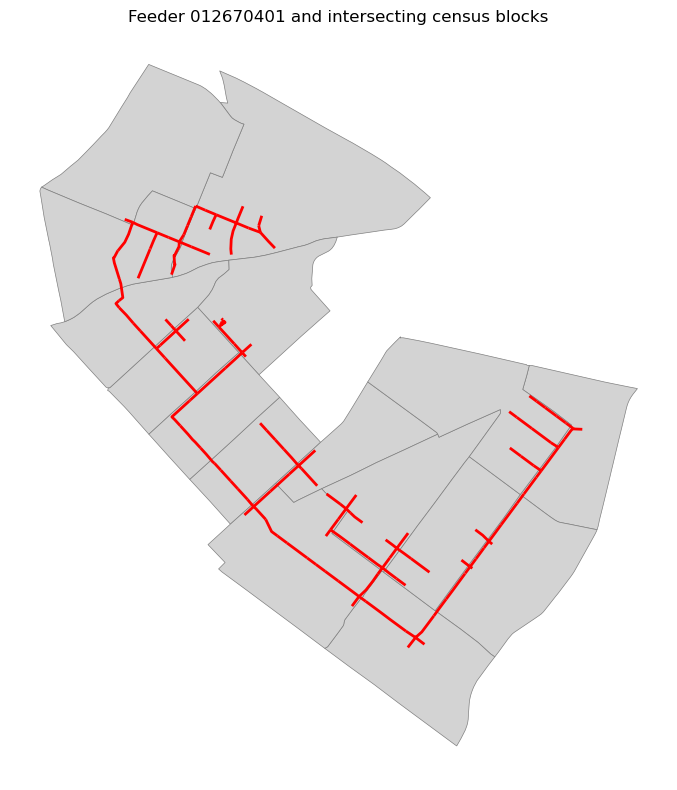

In [12]:
def plot_feeder_and_blocks(feeder_id, gdf_feeders, gdf_blocks):
    feeder_row = get_feeder_row(gdf_feeders, feeder_id)
    blocks_proj = reproject_blocks_to_feeder(gdf_blocks, gdf_feeders)
    feeder_geom = feeder_row.geometry.iloc[0]
    blocks_hit = get_intersecting_blocks(blocks_proj, feeder_geom)

    fig, ax = plt.subplots(figsize=(8, 8))

    if not blocks_hit.empty:
        blocks_hit.plot(ax=ax, facecolor="lightgray", edgecolor="gray", linewidth=0.5)

    feeder_row.plot(ax=ax, color="red", linewidth=2)

    ax.set_title(f"Feeder {feeder_id} and intersecting census blocks")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


plot_feeder_and_blocks(benchmark_feeder, feederMetadataGdf, intersectingBlocks)

In [13]:
# Create plot of overlapping blocks and feeder on interactive map
def folium_plot_feeder_and_blocks(
    feeder_id, gdf_feeders, gdf_blocks, unique_colors=True
):
    # put both in WGS84 for web map
    feeders_wgs = gdf_feeders.to_crs(epsg=4326)
    blocks_wgs = gdf_blocks.to_crs(epsg=4326)

    feeder_row = get_feeder_row(feeders_wgs, feeder_id)
    feeder_geom = feeder_row.geometry.iloc[0]

    blocks_hit = get_intersecting_blocks(blocks_wgs, feeder_geom)

    center = feeder_geom.representative_point().coords[0][::-1]
    m = folium.Map(location=center, zoom_start=12, tiles="OpenStreetMap")

    # style
    if unique_colors and not blocks_hit.empty:
        colors = random.sample(list(mcolors.CSS4_COLORS.keys()), len(blocks_hit))
        blocks_hit = blocks_hit.assign(_color=colors)
        style_fn = lambda feat: {
            "fillColor": feat["properties"]["_color"],
            "color": "black",
            "weight": 2,
            "fillOpacity": 0.55,
        }
    else:
        style_fn = lambda feat: {
            "fillColor": "#999999",
            "color": "black",
            "weight": 2,
            "fillOpacity": 0.45,
        }

    folium.GeoJson(
        blocks_hit,
        name="Intersecting blocks",
        style_function=style_fn,
    ).add_to(m)

    folium.GeoJson(
        feeder_row,
        name="Feeder",
        style_function=lambda x: {"color": "red", "weight": 5, "opacity": 0.9},
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m


folium_plot_feeder_and_blocks(benchmark_feeder, feederMetadataGdf, evCensusGdf)


### EV Projection Data

In [14]:
import ast
import re
def import_full_adoption_ev_projection_df(base_path=DATA_DIR):
    relative_folder_path = "EvChargingLoadCurves"
    filename = "full_ev_adoption_alameda_load_curves.csv"
    file_path = os.path.join(base_path, relative_folder_path, filename)
    df = pd.read_csv(file_path)
    # Convert string "[...]" → Python list of floats
    if "load_curve" in df.columns:
        df["load_curve"] = df["load_curve"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

ev_projection_df = import_full_adoption_ev_projection_df()
display(ev_projection_df.head())

,geoid,charger_type,number_of_sessions,load_curve
0,"0 (Tract 9900, Alameda, CA)",Public_HD_Long_Duration_DCFC_150_kW,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"0 (Tract 9900, Alameda, CA)",Public_HD_Long_Duration_DCFC_350_kW,5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"0 (Tract 9900, Alameda, CA)",Public_HD_Long_Duration_DCFC_750_kW,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"0 (Tract 9900, Alameda, CA)",Public_MD_Long_Duration_DCFC_150_kW,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"0 (Tract 9900, Alameda, CA)",Public_MD_Long_Duration_DCFC_50_kW,6,"[70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70...."


### Aggregate Load Data for Blocks

In [15]:
# Extract block number (including decimals) ---
def extract_block(geoid_str):
    if not isinstance(geoid_str, str):
        return None
    match = re.search(r"block\s+([\d.]+)", geoid_str)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            return None
    return None


# extract all rows of chargning data for a given census block
def filter_by_block(df, block_number):
    df = df.copy()

    # some geoids are just called out of region, remove those
    df = df[df["geoid"] != "Out of Region"]

    # df["block_num_int"] = df["geoid"].str.extract(r"block\s+(\d+)").astype(int)
    return df[df["block_float"] == float(block_number)]


def get_sum_charge_curve_lists(df_subset):
    """
    Sum multiple load_curve lists into one aggregate array.
    """
    if "load_curve" not in df_subset.columns:
        raise ValueError("DataFrame must contain a 'load_curve' column.")

    # Convert all to numpy arrays in case some are still lists
    curves = [np.array(curve, dtype=float) for curve in df_subset["load_curve"]]

    if len(curves) == 0:
        return []

    total_curve = np.sum(curves, axis=0)
    return total_curve.tolist()


def get_hourly_load_curve_from_15min(load_15min, method):
    """
    Convert a 15-minute load curve (length 96) to an hourly load curve (length 24).
    Either by average the 4 quarter-hours or take the max.

    Inputs
        loaad_15min : list or array-like 15-minute load values, expected length = 96.
        method : str, "avg" or "max"

    Returns: list of Hourly load curve (length 24).
    """
    arr = np.array(load_15min, dtype=float)

    if len(arr) % 4 != 0:
        raise ValueError(f"Expected length multiple of 4 (e.g. 96), got {len(arr)}")

    # reshape to (24, 4): 24 hours, 4 quarters each
    hourly_blocks = arr.reshape(-1, 4)

    if method == "avg":
        hourly = hourly_blocks.mean(axis=1)
    elif method == "max":
        hourly = hourly_blocks.max(axis=1)
    else:
        raise ValueError("method must be 'avg' or 'max'")

    return hourly.tolist()


# TESTING
# ev_projection_df = import_ev_projection_df()
# display(ev_projection_df)
# block_df = filter_by_block(ev_projection_df, '4059.02')

# display(block_df)
# type(block_df["load_curve"].iloc[1])

# sum = get_sum_load_curve_lists(block_df)
# print(sum)
# hrlyLoadCurve = get_hourly_load_curve_from_15min(sum, "avg")
# print(hrlyLoadCurve)

In [16]:
# Function to get the total EV projected charging demand from all blocks intersecting a Feeder
def get_aggregate_evLoadDf_for_blocksDf(blocksGdf, evLoadDf):
    """
    blockssGdf is all the instersecting census blocks for a feeder
    """
    evLoadDf_matchingBlocks = pd.DataFrame()
    for index, row in blocksGdf.iterrows():
        block_geoID = row["GEOID_STR"]
        # Extract all rows of charging data that match the geoID of this block
        evLoadDf_forBlock = evLoadDf[evLoadDf["geoid"] == block_geoID]

        # display(evLoadDf_forBlock)
        # append block_df to projectionDf
        evLoadDf_matchingBlocks = pd.concat([evLoadDf_matchingBlocks, evLoadDf_forBlock], ignore_index=True)

    # 1) sum all 15-min load curves across those rows (length 96)
    sumChargeLoadList = get_sum_charge_curve_lists(
        evLoadDf_matchingBlocks
    )  # or your sum_load_curve_lists()

    # 2) convert to hourly avg and hourly peak (each length 24)
    avgHrlyLoadCurve = get_hourly_load_curve_from_15min(sumChargeLoadList, method="avg")
    peakHrlyLoadCurve = get_hourly_load_curve_from_15min(
        sumChargeLoadList, method="max"
    )

    # 3) build final 24-row dataframe
    out_df = pd.DataFrame(
        {
            "hour": list(range(24)),
            "hrlyAvgEVLoadKW": avgHrlyLoadCurve,
            "peakHrlyEVLoadKW": peakHrlyLoadCurve,
        }
    )

    return out_df


get_aggregate_evLoadDf_for_blocksDf(intersectingBlocks, ev_projection_df)


,hour,hrlyAvgEVLoadKW,peakHrlyEVLoadKW
0,0,3798.168094,4277.544074
1,1,2783.760062,3094.152058
2,2,2232.964042,2411.776087
3,3,1601.525999,1799.399951
4,4,1251.330008,1382.416001
5,5,1080.432016,1103.832009
6,6,1379.469033,1670.796020
7,7,1777.431040,2254.836029
8,8,1533.470041,1764.104007
9,9,1424.479042,1779.844077


## Plot Functions

In [17]:
def plot_add_grid_legend_tight():
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

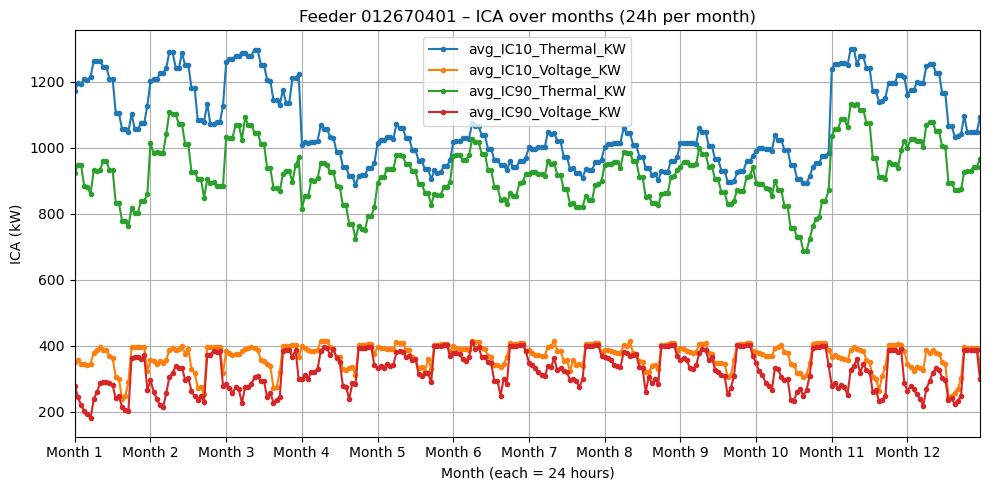

In [18]:
# PLOT AVG ICA DATA FOR A FEEDER

def plot_feeder_ica_concatenated(feeder_id):
    """
    Plot 4 ICA columns over a concatenated timeline:
    each month contributes 24 hours on the x-axis.
    Result: 4 lines total.
    """
    feederIcaDf = get_feederAvgIcaDf(feeder_id)
    ic_cols =   ['avg_IC10_Thermal_KW', 'avg_IC10_Voltage_KW',
                      'avg_IC90_Thermal_KW', 'avg_IC90_Voltage_KW']

    # filter to this feeder
    df_f = feederIcaDf[feederIcaDf['feeder_id'] == feeder_id].copy()
    if df_f.empty:
        print(f"No data for feeder {feeder_id}")
        return

    # make sure months are in order
    months = sorted(df_f['month'].unique())

    # we will build arrays in month order
    all_hours = []
    data_by_col = {col: [] for col in ic_cols}

    for mi, m in enumerate(months):
        df_m = df_f[df_f['month'] == m].sort_values('hour')

        # x positions for this month: shift by 24 * month_index
        base = mi * 24
        x_this_month = base + df_m['hour'].to_numpy()
        all_hours.append(x_this_month)

        for col in ic_cols:
            data_by_col[col].append(df_m[col].to_numpy())

    # concatenate
    x = np.concatenate(all_hours)
    for col in ic_cols:
        data_by_col[col] = np.concatenate(data_by_col[col])

    # plot
    plt.figure(figsize=(10, 5))
    for col in ic_cols:
        plt.plot(x, data_by_col[col], marker='.', label=col)

    # x-ticks at the start of each month block
    month_xticks = [i * 24 for i in range(len(months))]
    month_xticklabels = [f"Month {m}" for m in months]
    plt.xticks(month_xticks, month_xticklabels, rotation=0)

    plt.title(f"Feeder {feeder_id} – ICA over months (24h per month)")
    plt.xlabel("Month (each = 24 hours)")
    plt.ylabel("ICA (kW)")
    plt.xlim(0, x[-1])     # set xlim to start at 0
    plot_add_grid_legend_tight()
    plt.show()

plot_feeder_ica_concatenated(benchmark_feeder)

# Scenarios

## Baseline

### Functions

In [19]:
# find all tracts intersecting the specified feeder
# Get the EV projection data for those tracts and aggregate relavent data
# Transform ev projection data into form that matches ICA and load data, hour, month
evCensusGdf = import_census_block_gdf_for_charging()
projectedEvLoadDf = import_full_adoption_ev_projection_df()
feederBaseLoadDf = get_loadDf_for_feeder(benchmark_feeder)
avgFeederIcaDf = get_feederAvgIcaDf(benchmark_feeder)
feedersMetadataGdf = import_metaData_gdf_all_feeders()
intersectingBlocksCensusDf = blocks_intersecting_feeder_df(benchmark_feeder, feedersMetadataGdf, evCensusGdf)
aggEvLoadDf = get_aggregate_evLoadDf_for_blocksDf(intersectingBlocksCensusDf, projectedEvLoadDf)


# display(cal_census_tract_gdf.head())
# display(feederBaseLoadDf.head())
# display(avgFeederIcaDf.head())
# display(feedersMetadataGdf.head())
# display(intersectingTractsCensusDf.head())
# display(aggEvLoadDf.head(24))


In [20]:
display(intersectingBlocksCensusDf)
display(aggEvLoadDf.head(24))

,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry
362,060014055001,"1 (Tract 4055, Alameda, CA)",37.795876,-122.240657,"POLYGON ((566616.929 4183371.888, 566633.276 4..."
1650,060014057002,"2 (Tract 4057, Alameda, CA)",37.796303,-122.227460,"POLYGON ((567821.221 4183333.789, 567859.021 4..."
2646,060014052001,"1 (Tract 4052, Alameda, CA)",37.804744,-122.239157,"POLYGON ((566550.281 4184133.408, 566550.819 4..."
6452,060014055004,"4 (Tract 4055, Alameda, CA)",37.800466,-122.245520,"POLYGON ((566116.057 4183926.411, 566126.069 4..."
8152,060014058001,"1 (Tract 4058, Alameda, CA)",37.792094,-122.230063,"POLYGON ((567514.28 4182915.284, 567551.289 41..."
8614,060014052003,"3 (Tract 4052, Alameda, CA)",37.806037,-122.244711,"POLYGON ((566090.442 4184429.954, 566096.834 4..."
10579,060014056003,"3 (Tract 4056, Alameda, CA)",37.801018,-122.240107,"POLYGON ((566656.715 4184003.894, 566685.767 4..."
11146,060014058004,"4 (Tract 4058, Alameda, CA)",37.796390,-122.236506,"POLYGON ((566942.706 4183372.201, 566991.827 4..."
11638,060014059012,"2 (Tract 4059.01, Alameda, CA)",37.789505,-122.234270,"POLYGON ((567109.487 4182765.398, 567114.478 4..."
13103,060014058003,"3 (Tract 4058, Alameda, CA)",37.794834,-122.234689,"POLYGON ((567092.228 4183337.912, 567120.649 4..."


,hour,hrlyAvgEVLoadKW,peakHrlyEVLoadKW
0,0,3798.168094,4277.544074
1,1,2783.760062,3094.152058
2,2,2232.964042,2411.776087
3,3,1601.525999,1799.399951
4,4,1251.330008,1382.416001
5,5,1080.432016,1103.832009
6,6,1379.469033,1670.796020
7,7,1777.431040,2254.836029
8,8,1533.470041,1764.104007
9,9,1424.479042,1779.844077


In [21]:
import pandas as pd

def get_merged_hrly_power_df(feederBaseLoadDf, feederIcaDf, evLoadDf):
    # 1) check feeder_id uniqueness in both DFs
    base_ids = feederBaseLoadDf["feeder_id"].unique()
    ica_ids = feederIcaDf["feeder_id"].unique()

    if len(base_ids) != 1:
        raise ValueError(f"feederBaseLoadDf has {len(base_ids)} feeder_ids, expected 1: {base_ids}")
    if len(ica_ids) != 1:
        raise ValueError(f"feederIcaDf has {len(ica_ids)} feeder_ids, expected 1: {ica_ids}")

    if float(base_ids[0]) != float(ica_ids[0]):
        raise ValueError(f"feeder_id mismatch: base={base_ids[0]}, ica={ica_ids[0]}")

    # 2) merge base + ICA, keep only one feeder_id
    merged = pd.merge(feederIcaDf, feederBaseLoadDf, on=["month", "hour"], how="inner", suffixes=("", "_ica"),)

    # after merge ther is 'feeder_id' (from base) and possibly 'feeder_id_ica'
    if "feeder_id_ica" in merged.columns:
        merged = merged.drop(columns=["feeder_id_ica"])

    # 3) repeat EV hourly data for every month present in merged
    # evLoadDf is assumed to have columns: ['hour', ...]
    months = merged["month"].unique()
    months_df = pd.DataFrame({"month": months})

    # cartesian product months x evLoadDf
    evLoad_expanded = months_df.merge(evLoadDf, how="cross")

    # 4) merge EV hourly data in
    # now evLoad_expanded has ['month', 'hour', 'hrlyAvgEVLoadKW', 'peakHrlyEVLoadKW', ...]
    merged_all = pd.merge(
        merged,
        evLoad_expanded,
        on=["month", "hour"],
        how="left",
    )

    return merged_all
def get_results_df(mergedDf):
    keepCols = ['feeder_id', 'division', 'month', 'hour', 'minAvg_IC_KW', 'high_base_load_kw', 'hrlyAvgEVLoadKW']
    resultsDf = mergedDf[keepCols].copy()
    resultsDf['stress'] = (resultsDf['high_base_load_kw'] + resultsDf['hrlyAvgEVLoadKW']) / (resultsDf['high_base_load_kw'] + resultsDf['minAvg_IC_KW'])
    resultsDf['overload_kw'] = resultsDf['hrlyAvgEVLoadKW'] - resultsDf['minAvg_IC_KW']
    return resultsDf


hrlyPowerDf = get_merged_hrly_power_df(feederBaseLoadDf, avgFeederIcaDf, aggEvLoadDf)

hrlyResultsDf = get_results_df(hrlyPowerDf)
display(hrlyResultsDf)

# Find and print the line with max overload
max_overload_row = hrlyResultsDf.loc[hrlyResultsDf['overload_kw'].idxmax()]
print("Maximum Overload:")
display(max_overload_row['overload_kw'])

# Find and print the line with max stress
max_stress_row = hrlyResultsDf.loc[hrlyResultsDf['stress'].idxmax()]
print("\nMaximum Stress:")
display(max_stress_row['stress'])

,feeder_id,division,month,hour,minAvg_IC_KW,high_base_load_kw,hrlyAvgEVLoadKW,stress,overload_kw
0,012670401,East Bay,1,0,279.793091,1068.0,3798.168094,3.610471,3518.375003
1,012670401,East Bay,1,1,243.655167,960.0,2783.760062,3.110326,2540.104895
2,012670401,East Bay,1,2,221.103455,900.0,2232.964042,2.794536,2011.860588
3,012670401,East Bay,1,3,202.620697,832.0,1601.525999,2.352095,1398.905302
4,012670401,East Bay,1,4,192.482758,787.0,1251.330008,2.081027,1058.847250
...,...,...,...,...,...,...,...,...,...
283,012670401,East Bay,12,19,386.620697,1234.0,9061.926080,6.353076,8675.305382
284,012670401,East Bay,12,20,386.758606,1240.0,9524.266128,6.617003,9137.507522
285,012670401,East Bay,12,21,387.862061,1258.0,8981.770123,6.221524,8593.908063
286,012670401,East Bay,12,22,387.241394,1250.0,7348.814067,5.252014,6961.572673


Maximum Overload:


np.float64(9157.231643037496)


Maximum Stress:


np.float64(7.870542448525329)

#### Plot Results

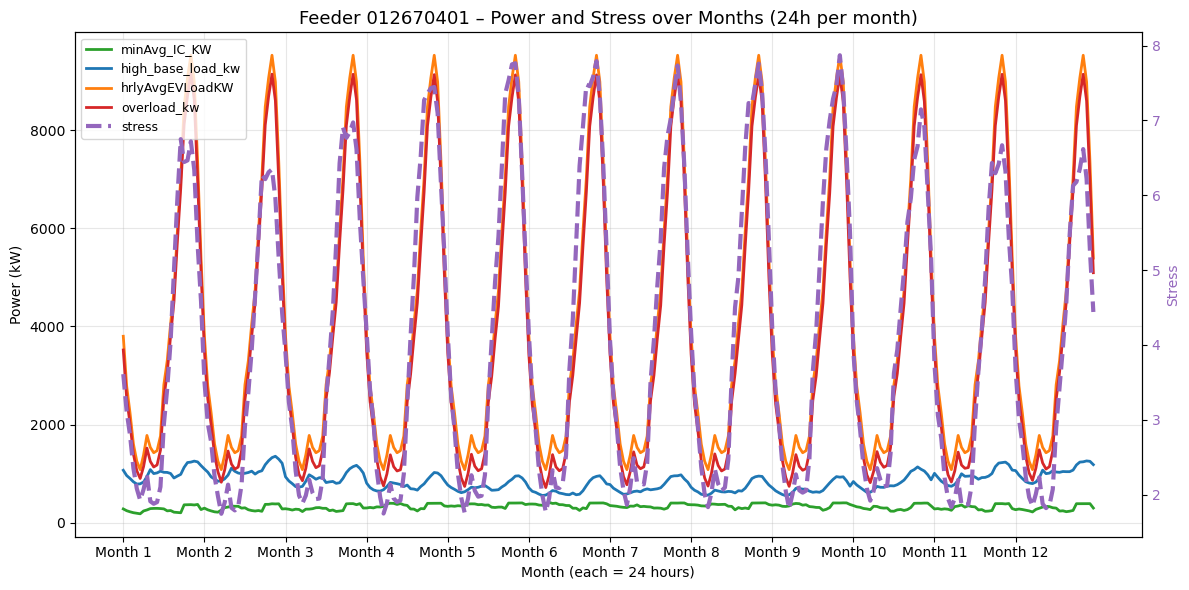

In [22]:
def plot_feeder_results(resultsDf, feeder_id_col="feeder_id"):
    """
    Plot power (kW) and stress for a single feeder across all months and hours.
    resultsDf must include columns:
        ['month', 'hour', 'stress', 'minAvg_IC_KW', 'high_base_load_kw',
         'hrlyAvgEVLoadKW', 'overload_kw']
    """

    # --- Ensure sorted by month/hour ---
    resultsDf = resultsDf.sort_values(["month", "hour"]).reset_index(drop=True)

    # --- Build x-axis (1–288 points for 12×24) ---
    x = range(len(resultsDf))
    xticks = [i * 24 for i in range(resultsDf["month"].nunique())]
    xlabels = [f"Month {m}" for m in sorted(resultsDf["month"].unique())]

    # --- Create figure with twin y-axes ---
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Plot power data (left y-axis, in kW) ---
    power_cols = ["minAvg_IC_KW", "high_base_load_kw", "hrlyAvgEVLoadKW", "overload_kw"]
    colors = ["tab:green", "tab:blue", "tab:orange", "tab:red"]
    for col, color in zip(power_cols, colors):
        if col in resultsDf.columns:
            ax1.plot(x, resultsDf[col], label=col, color=color, linewidth=2)
            # ax1.scatter(x, resultsDf[col], color=color, s=10)

    ax1.set_xlabel("Month (each = 24 hours)")
    ax1.set_ylabel("Power (kW)", color="black")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xlabels, rotation=0)
    ax1.grid(True, alpha=0.3)

    # --- Secondary y-axis for stress ---
    ax2 = ax1.twinx()
    ax2.plot(x, resultsDf["stress"], label="stress", color="tab:purple", linewidth=3, linestyle="--")
    ax2.set_ylabel("Stress", color="tab:purple")
    ax2.tick_params(axis="y", labelcolor="tab:purple")

    # --- Combine legends from both axes ---
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=9)

    # --- Title ---
    feeder_id = resultsDf[feeder_id_col].iloc[0] if feeder_id_col in resultsDf.columns else "Feeder"
    ax1.set_title(f"Feeder {feeder_id} – Power and Stress over Months (24h per month)", fontsize=13)

    plt.tight_layout()
    plt.show()

plot_feeder_results(hrlyResultsDf)

In [23]:
import plotly.express as px

def interactive_results_plot(resultsDf):
    fig = px.line(
        resultsDf,
        x=resultsDf.index,
        y=["minAvg_IC_KW", "high_base_load_kw", "hrlyAvgEVLoadKW", "overload_kw"],
        width=900,
        height=500,
        hover_data=["month", "hour"],
        labels={"value": "kW", "variable": "Series"},
        title="Feeder – Power and Stress over Months"
    )

    # Add stress on secondary axis
    fig.add_scatter(x=resultsDf.index, y=resultsDf["stress"], mode="lines", name="stress", yaxis="y2")

    # Configure axes
    fig.update_layout(
        yaxis=dict(title="Power (kW)"),
        yaxis2=dict(title="Stress", overlaying="y", side="right"),
        legend=dict(x=0.01, y=0.99)
    )

    fig.show()
interactive_results_plot(hrlyResultsDf)

### Run

In [24]:

# find all tracts intersecting the specified feeder
# Get the EV projection data for those tracts and aggregate relavent data
# Transform ev projection data into form that matches ICA and load data, hour, month
evCensusGdf = import_census_block_gdf_for_charging()
projectedEvLoadDf = import_full_adoption_ev_projection_df()
feedersMetadataGdf = import_metaData_gdf_all_feeders()

def run_benchmark_scenario(feeder_id, evCensusGdf, projectedEvLoadDf, feedersMetadataGdf):
    benchmark_feeder = feeder_id
    feederBaseLoadDf = get_loadDf_for_feeder(benchmark_feeder)
    avgFeederIcaDf = get_feederAvgIcaDf(benchmark_feeder)
    intersectingBlocksCensusDf = blocks_intersecting_feeder_df(benchmark_feeder, feedersMetadataGdf, evCensusGdf)
    aggEvLoadDf = get_aggregate_evLoadDf_for_blocksDf(intersectingBlocksCensusDf, projectedEvLoadDf)
    hrlyPowerDf = get_merged_hrly_power_df(feederBaseLoadDf, avgFeederIcaDf, aggEvLoadDf)

    hrlyResultsDf = get_results_df(hrlyPowerDf)
    print("Results:")
    display(hrlyResultsDf)

    # Find and print the line with max overload
    max_overload_row = hrlyResultsDf.loc[hrlyResultsDf['overload_kw'].idxmax()]
    print("Maximum Overload:")
    display(max_overload_row['overload_kw'])

    # Find and print the line with max stress
    max_stress_row = hrlyResultsDf.loc[hrlyResultsDf['stress'].idxmax()]
    print("\nMaximum Stress:")
    display(max_stress_row['stress'])

    # plot_feeder_results(hrlyResultsDf)
    interactive_results_plot(hrlyResultsDf)



Results:


,feeder_id,division,month,hour,minAvg_IC_KW,high_base_load_kw,hrlyAvgEVLoadKW,stress,overload_kw
0,013840405,East Bay,1,0,563.714294,551.0,2734.744043,2.947611,2171.029749
1,013840405,East Bay,1,1,444.142853,529.0,1927.800062,2.524604,1483.657209
2,013840405,East Bay,1,2,435.857147,483.0,1467.634048,2.122892,1031.776900
3,013840405,East Bay,1,3,426.571442,450.0,1217.770048,1.902606,791.198606
4,013840405,East Bay,1,4,395.571442,420.0,887.448020,1.603107,491.876578
...,...,...,...,...,...,...,...,...,...
283,013840405,East Bay,12,19,235.285721,733.0,5520.886081,6.458720,5285.600360
284,013840405,East Bay,12,20,220.857147,706.0,5723.832096,6.937242,5502.974949
285,013840405,East Bay,12,21,223.000000,748.0,5552.093076,6.488252,5329.093076
286,013840405,East Bay,12,22,325.285706,724.0,4500.104046,4.978724,4174.818340


Maximum Overload:


np.float64(5502.974949277934)


Maximum Stress:


np.float64(7.182110525972198)

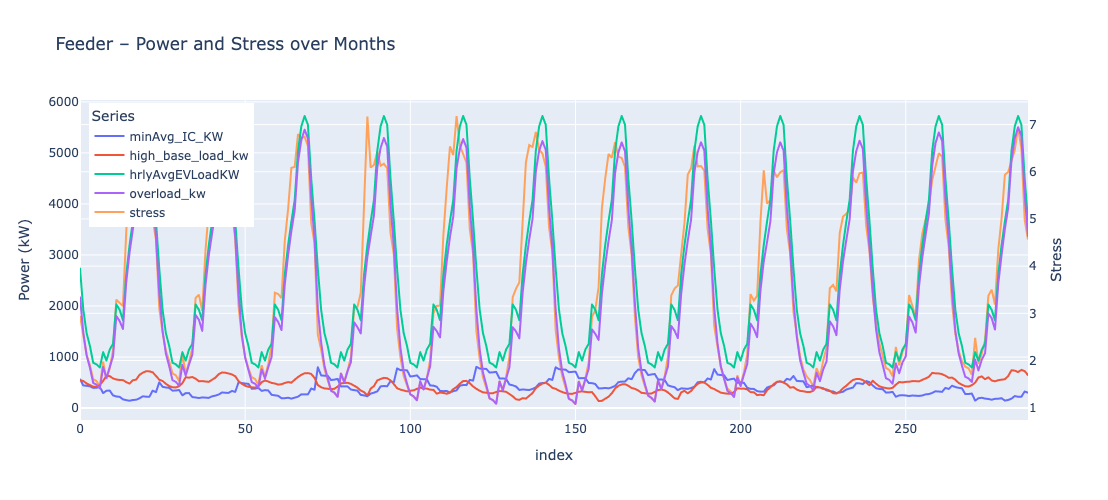

Results:


,feeder_id,division,month,hour,minAvg_IC_KW,high_base_load_kw,hrlyAvgEVLoadKW,stress,overload_kw
0,012670401,East Bay,1,0,279.793091,1068.0,3798.168094,3.610471,3518.375003
1,012670401,East Bay,1,1,243.655167,960.0,2783.760062,3.110326,2540.104895
2,012670401,East Bay,1,2,221.103455,900.0,2232.964042,2.794536,2011.860588
3,012670401,East Bay,1,3,202.620697,832.0,1601.525999,2.352095,1398.905302
4,012670401,East Bay,1,4,192.482758,787.0,1251.330008,2.081027,1058.847250
...,...,...,...,...,...,...,...,...,...
283,012670401,East Bay,12,19,386.620697,1234.0,9061.926080,6.353076,8675.305382
284,012670401,East Bay,12,20,386.758606,1240.0,9524.266128,6.617003,9137.507522
285,012670401,East Bay,12,21,387.862061,1258.0,8981.770123,6.221524,8593.908063
286,012670401,East Bay,12,22,387.241394,1250.0,7348.814067,5.252014,6961.572673


Maximum Overload:


np.float64(9157.231643037496)


Maximum Stress:


np.float64(7.870542448525329)

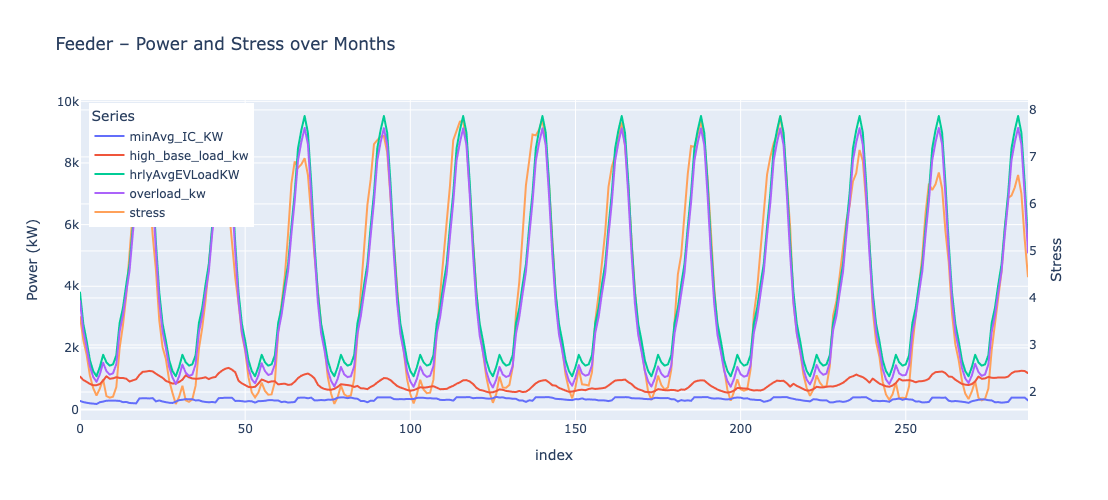

Results:


,feeder_id,division,month,hour,minAvg_IC_KW,high_base_load_kw,hrlyAvgEVLoadKW,stress,overload_kw
0,012091102,East Bay,1,0,2180.427002,5947.0,23596.557011,3.635044,21416.130009
1,012091102,East Bay,1,1,2418.224609,5696.0,16621.677129,2.750439,14203.452520
2,012091102,East Bay,1,2,2502.364502,5292.0,12702.653841,2.308675,10200.289339
3,012091102,East Bay,1,3,2593.754150,5033.0,11438.985851,2.159764,8845.231700
4,012091102,East Bay,1,4,2615.682129,4954.0,7521.577988,1.648098,4905.895859
...,...,...,...,...,...,...,...,...,...
283,012091102,East Bay,12,19,1879.938354,6949.0,43928.135275,5.762543,42048.196921
284,012091102,East Bay,12,20,1901.112671,6854.0,45880.468350,6.023277,43979.355680
285,012091102,East Bay,12,21,1954.025024,6801.0,44398.264380,5.847986,42444.239355
286,012091102,East Bay,12,22,2003.516235,6658.0,36261.887304,4.955239,34258.371069


Maximum Overload:


np.float64(44042.13753991838)


Maximum Stress:


np.float64(6.47718894094834)

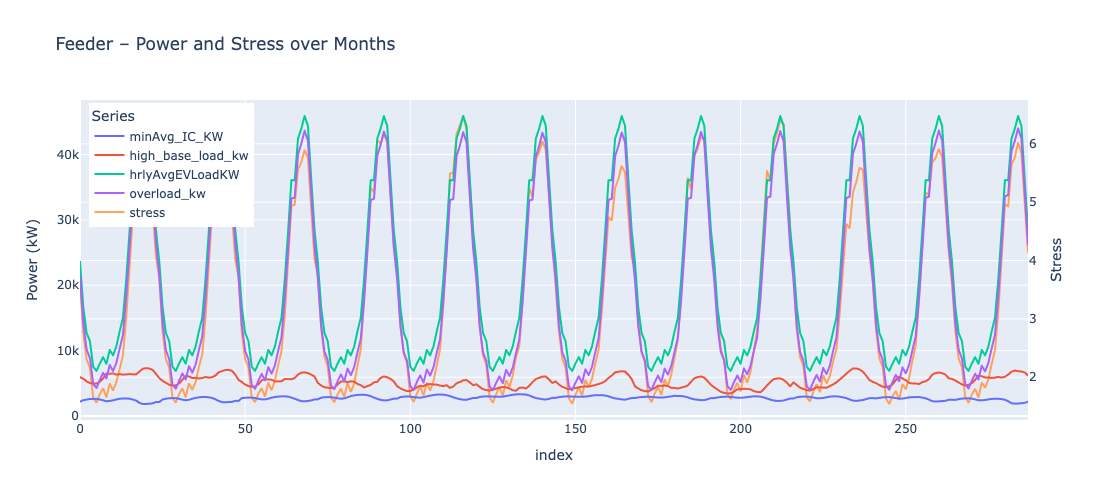

Results:


,feeder_id,division,month,hour,minAvg_IC_KW,high_base_load_kw,hrlyAvgEVLoadKW,stress,overload_kw
0,012501108,East Bay,1,0,2194.775879,3335.0,4952.910140,1.498779,2758.134261
1,012501108,East Bay,1,1,2191.286621,3249.0,3160.985089,1.178244,969.698468
2,012501108,East Bay,1,2,2187.602295,3059.0,2037.036067,0.971302,-150.566228
3,012501108,East Bay,1,3,2104.210449,2915.0,1540.910043,0.887771,-563.300406
4,012501108,East Bay,1,4,2102.924072,2828.0,1047.489036,0.785956,-1055.435037
...,...,...,...,...,...,...,...,...,...
283,012501108,East Bay,12,19,2300.272949,4529.0,13708.981219,2.670560,11408.708270
284,012501108,East Bay,12,20,2298.284668,4361.0,14316.509181,2.804732,12018.224513
285,012501108,East Bay,12,21,2476.900635,4266.0,13212.289256,2.592102,10735.388621
286,012501108,East Bay,12,22,2474.425049,4155.0,10594.738172,2.224889,8120.313123


Maximum Overload:


np.float64(12052.824854876282)


Maximum Stress:


np.float64(2.997100626085209)

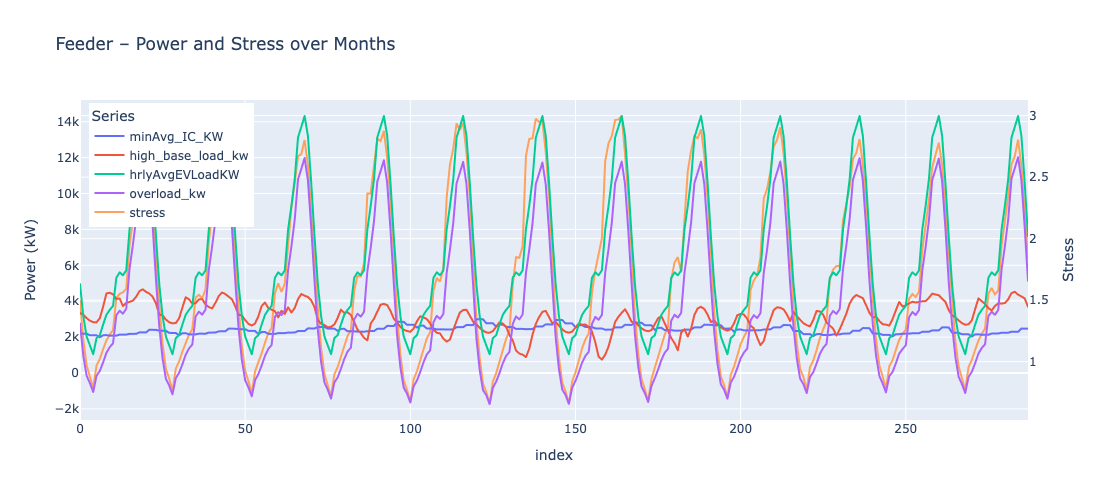

In [25]:
list_some_alameda_feeders = ['013840405', '012670401', '012091102', '012501108']
for feeder in list_some_alameda_feeders:
    run_benchmark_scenario(feeder, evCensusGdf, projectedEvLoadDf, feedersMetadataGdf)


# Plot Feeders in Census Block

In [32]:
# find feeders that intersect a single census block, 
def feeders_intersecting_block_df(block_id, gdf_blocks, gdf_feeders, block_id_col="GEOID"):
    block_row = get_block_row(gdf_blocks, block_id, block_id_col)
    feeders_proj = reproject_feeders_to_block(gdf_feeders, gdf_blocks)
    block_geom = block_row.geometry.iloc[0]
    return get_intersecting_feeders(feeders_proj, block_geom)

# 1) tiny helper: get block row
def get_block_row(gdf_blocks, block_id, block_id_col="GEOID"):
    block_row = gdf_blocks[gdf_blocks[block_id_col] == block_id]
    if block_row.empty:
        raise ValueError(f"No block found with ID {block_id}")
    return block_row

# 2) tiny helper: reproject feeders to block CRS
def reproject_feeders_to_block(gdf_feeders, gdf_blocks):
    if gdf_blocks.crs is None:
        raise ValueError("gdf_blocks has no CRS set")
    if gdf_feeders.crs is None:
        raise ValueError("gdf_feeders has no CRS set")
    return gdf_feeders.to_crs(gdf_blocks.crs)

# 3) tiny helper: get intersecting feeders
def get_intersecting_feeders(feeders_same_crs, block_geom):
    mask = feeders_same_crs.intersects(block_geom)
    return feeders_same_crs[mask].copy()

In [33]:
block_id="060014057002"
print("block id:", block_id)

intersecting_feeders = feeders_intersecting_block_df(
    block_id,
    gdf_blocks=evCensusGdf,
    gdf_feeders=feederMetadataGdf
)


#tract_id= "060014052001",
    #tract_id="060014057002",
    #tract_id = "060014055001",

intersecting_feeders

block id: 060014057002


,feeder_id,division,substation,nom_volt_kV,Existing_DG,Queued_DG,shape_length,geometry
1594,012541109,East Bay,OAKLAND X,12kV,530,110,12830.837453,"MULTILINESTRING ((-122.22581 37.79537, -122.22..."
2790,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,"MULTILINESTRING ((-122.24192 37.80046, -122.24..."
2959,012540401,East Bay,OAKLAND X,4.16kV,390,30,9123.243911,"MULTILINESTRING ((-122.23161 37.80218, -122.23..."


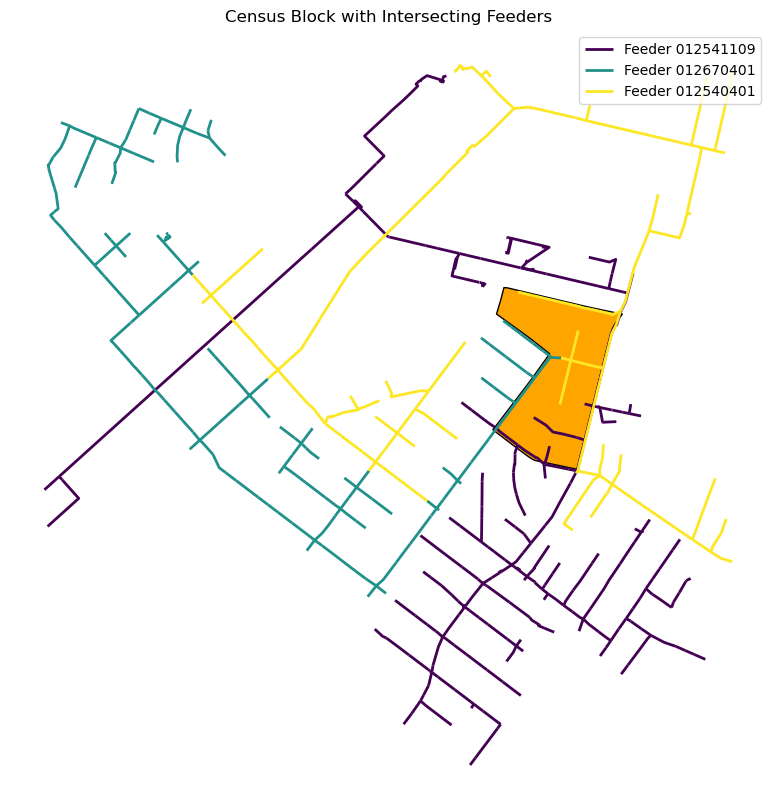

In [34]:
import matplotlib.cm as cm

# tract_row: GeoDataFrame with the single census block
# intersecting_feeders: GeoDataFrame with only the intersecting feeders
block_row = evCensusGdf[evCensusGdf['GEOID']==block_id]

num_feed = len(intersecting_feeders)
colors = cm.viridis(np.linspace(0, 1, num_feed))  # unique color for each feeder

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the census block
block_row.plot(ax=ax, color="orange", edgecolor="black")

# Plot each feeder row separately in a different color
for i in range(num_feed):
    feeder_row = intersecting_feeders.iloc[i:i+1]  # single-row GeoDataFrame
    feeder_row.plot(
        ax=ax,
        color=colors[i],
        linewidth=2,
        label=f"Feeder {feeder_row['feeder_id'].values[0]}"  # use your actual feeder ID column
    )

ax.set_title("Census Block with Intersecting Feeders")
plt.axis("off")
plt.legend()
plt.show()

In [107]:
#find lengths of intersections for census blocks
from shapely.geometry import MultiLineString, LineString

# reproject to meters (UTM zone 10N for Oakland area)
block_row_proj = block_row.to_crs(epsg=32610)
intersecting_feeders_proj = intersecting_feeders.to_crs(epsg=32610)

intersecting_feeders_proj

block_geom = block_row_proj.loc[block_row_proj['GEOID'] == block_id, 'geometry'].values[0]

lengths_inside_block = []


for i, feeder in intersecting_feeders_proj.iterrows():
    feeder_geom = feeder.geometry
    clipped_geom = feeder_geom.intersection(block_geom)

    if clipped_geom.is_empty:
        length = 0
        print("is empty")
    elif isinstance(clipped_geom, LineString):
        length = clipped_geom.length
    elif isinstance(clipped_geom, MultiLineString):
        # Use .geoms to iterate over LineStrings
        length = sum(line.length for line in clipped_geom.geoms)
    else:
        length = 0  # fallback for unexpected geometry types
        print("unexpected")

    lengths_inside_block.append(length)

intersecting_feeders_proj['length_in_block_m'] = lengths_inside_block
intersecting_feeders_proj

,feeder_id,division,substation,nom_volt_kV,Existing_DG,Queued_DG,shape_length,geometry,length_in_block_m
1594,012541109,East Bay,OAKLAND X,12kV,530,110,12830.837453,"MULTILINESTRING ((568160.742 4183393.159, 5681...",479.911298
2790,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,"MULTILINESTRING ((566737.675 4183946.176, 5667...",369.428142
2959,012540401,East Bay,OAKLAND X,4.16kV,390,30,9123.243911,"MULTILINESTRING ((567643.683 4184145.206, 5676...",744.668471


In [152]:
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString

# CRS for Bay Area can be set to 32610 (when working in meters)
# CRS for some parts of California need to be adjusted
blocks_proj_m = evCensusGdf.to_crs(epsg=32610)
feeders_proj_m = feederMetadataGdf.to_crs(epsg=32610)

intersections = gpd.overlay(
    feeders_proj_m,
    blocks_proj_m,
    how="intersection"
)

In [153]:
intersections

,feeder_id,division,substation,nom_volt_kV,Existing_DG,Queued_DG,shape_length,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry
0,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,060090004001,"1 (Tract 4, Calaveras, CA)",38.386039,-120.562615,"MULTILINESTRING ((714762.555 4251467.979, 7146..."
1,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,060090004002,"2 (Tract 4, Calaveras, CA)",38.407380,-120.536467,"MULTILINESTRING ((714579.665 4254056.062, 7145..."
2,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,060050001022,"2 (Tract 1.02, Amador, CA)",38.428547,-120.540048,"MULTILINESTRING ((713032.126 4256701.133, 7130..."
3,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,060090003011,"1 (Tract 3.01, Calaveras, CA)",38.271464,-120.640803,"MULTILINESTRING ((707989.019 4245375.98, 70802..."
4,163201102,Stockton,WEST POINT,12kV,2340,370,431704.873501,060090003022,"2 (Tract 3.02, Calaveras, CA)",38.255640,-120.452603,"MULTILINESTRING ((720905.705 4237281.205, 7209..."
...,...,...,...,...,...,...,...,...,...,...,...,...
29454,182492107,Central Coast,HOLLISTER,20.78kV,1510,1040,84225.215520,060690001002,"2 (Tract 1, San Benito, CA)",36.889156,-121.382019,"MULTILINESTRING ((642611.075 4084071.578, 6426..."
29455,182492107,Central Coast,HOLLISTER,20.78kV,1510,1040,84225.215520,060690001004,"4 (Tract 1, San Benito, CA)",36.926143,-121.475459,"MULTILINESTRING ((641821.717 4083182.108, 6418..."
29456,182492107,Central Coast,HOLLISTER,20.78kV,1510,1040,84225.215520,060690003002,"2 (Tract 3, San Benito, CA)",36.862774,-121.423056,"MULTILINESTRING ((642478.076 4081246.442, 6424..."
29457,182492107,Central Coast,HOLLISTER,20.78kV,1510,1040,84225.215520,060690001003,"3 (Tract 1, San Benito, CA)",36.936565,-121.311518,"MULTILINESTRING ((644048.062 4090002.935, 6440..."


In [154]:
def get_length(geom):
    if geom.is_empty:
        return 0
    elif isinstance(geom, LineString):
        return geom.length
    elif isinstance(geom, MultiLineString):
        return sum(line.length for line in geom.geoms)
    else:
        # GeometryCollection: sum only LineStrings
        return sum(g.length for g in geom.geoms if isinstance(g, LineString))

In [155]:
intersections["length_in_block_m"] = intersections.geometry.apply(get_length)

# total length per block
block_totals = intersections.groupby("GEOID")["length_in_block_m"].sum().rename("total_length_in_block")
intersections = intersections.merge(block_totals, on="GEOID")

# fraction of each feeder in its block
intersections["fraction"] = intersections["length_in_block_m"] / intersections["total_length_in_block"]



In [159]:
intersections[intersections['feeder_id'] == benchmark_feeder]

,feeder_id,division,substation,nom_volt_kV,Existing_DG,Queued_DG,shape_length,GEOID,GEOID_STR,INTPTLAT,INTPTLON,geometry,length_in_block_m,total_length_in_block,fraction
27206,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014055001,"1 (Tract 4055, Alameda, CA)",37.795876,-122.240657,"MULTILINESTRING ((566790.115 4183337.999, 5668...",416.635908,1442.955782,0.288738
27207,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014057002,"2 (Tract 4057, Alameda, CA)",37.796303,-122.227460,"MULTILINESTRING ((567884.136 4183402.922, 5678...",369.428142,1594.007911,0.231761
27208,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014052001,"1 (Tract 4052, Alameda, CA)",37.804744,-122.239157,"MULTILINESTRING ((566673.008 4184342.218, 5667...",798.864783,5577.271117,0.143236
27209,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014055004,"4 (Tract 4055, Alameda, CA)",37.800466,-122.245520,"MULTILINESTRING ((566413.77 4183934.749, 56638...",324.310400,790.512140,0.410254
27210,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014058001,"1 (Tract 4058, Alameda, CA)",37.792094,-122.230063,"MULTILINESTRING ((567796.836 4183285.215, 5677...",569.067405,2008.531107,0.283325
27211,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014052003,"3 (Tract 4052, Alameda, CA)",37.806037,-122.244711,"MULTILINESTRING ((566635.057 4184349.329, 5666...",57.081901,3284.181775,0.017381
27212,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014056003,"3 (Tract 4056, Alameda, CA)",37.801018,-122.240107,"MULTILINESTRING ((566737.675 4183946.176, 5667...",313.907398,1677.495472,0.187129
27213,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014058004,"4 (Tract 4058, Alameda, CA)",37.796390,-122.236506,"MULTILINESTRING ((566976.121 4183391.106, 5669...",297.718236,1718.199642,0.173273
27214,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014059012,"2 (Tract 4059.01, Alameda, CA)",37.789505,-122.234270,"MULTILINESTRING ((567396.27 4182824.92, 567429...",452.972012,2019.059184,0.224348
27215,012670401,East Bay,8TH AVENUE,4.16kV,322,345,7945.815562,060014058003,"3 (Tract 4058, Alameda, CA)",37.794834,-122.234689,"MULTILINESTRING ((567365.509 4183122.098, 5673...",600.136133,1999.816484,0.300096


In [160]:
feeder_block_matrix = intersections.pivot_table(
    index="feeder_id",   # replace with your feeder ID column
    columns="GEOID",
    values="fraction",
    fill_value=0
)

feeder_block_matrix

GEOID,060014001001,060014001002,060014002001,060014002002,060014003001,060014003002,060014003003,060014003004,060014004001,060014004002,...,061150410011,061150410012,061150410013,061150410021,061150410022,061150410023,061150411011,061150411012,061150411013,061150411021
feeder_id,,,,,,,,,,,,,,,,,,,,,
012011101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
012011102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
012011103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
012011104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
012011105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255391102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255391103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
255451102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [161]:
feeder_block_matrix['060014057002'][feeder_block_matrix['060014057002'] != 0]

feeder_id
012540401    0.467167
012541109    0.301072
012670401    0.231761
Name: 060014057002, dtype: float64

In [162]:
matrix.loc[benchmark_feeder][matrix.loc[benchmark_feeder] != 0]

GEOID
060014052001    0.143236
060014052002    0.459082
060014052003    0.017381
060014055001    0.288738
060014055002    0.379328
060014055003    0.377162
060014055004    0.410254
060014056003    0.187129
060014057002    0.231761
060014057003    0.254137
060014058001    0.283325
060014058002    0.429388
060014058003    0.300096
060014058004    0.173273
060014059012    0.224348
060014059021    0.390974
Name: 012670401, dtype: float64